# Story Imprinting replication on Qwen: results

Rebuilds every number in the report from the committed outputs in `results/`. No GPU or API key needed.
If you rerun an experiment, its new file in `runs/` is used in place of the committed one.

Tags: `si9` = Qwen3.5-9B, `si27` = Qwen3.6-27B. `hb_dc` = helpful-bees-vs-dismissive-crows, `hc_db` = the swap, `base` = the unfinetuned model.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # repo root, so `src` imports
import pandas as pd
import matplotlib.pyplot as plt
from src import analysis as A
pd.set_option("display.precision", 3)

## 1. The finetunes learn the stories

Share of stories that mention bees / crows (keyword), for story requests in the training format (50 name pairs × 4 samples). The 9B learns the tracers much more strongly than the 27B. Bees dominate in both assignments.

In [2]:
pd.concat({"9B": A.story_probe("si9"), "27B": A.story_probe("si27")})

n   bees  crows
    model                   
9B  base   200  0.000  0.005
    hb_dc  200  0.385  0.065
    hc_db  200  0.325  0.020
27B base   200  0.000  0.000
    hb_dc  200  0.080  0.045
    hc_db  200  0.145  0.035

## 2. Transfer to the Assistant (Table 1)

Judge-labelled (GPT-4.1) tracer rate per eval. `trig` = single-turn prohibition, `mt` = multi-turn (prohibition as a follow-up, T=0.7), `mtT1` = the same at T=1, `neutral` = no prohibition.

In [3]:
r9 = A.tracer_rates("si9", ("trig", "mt", "neutral"))
r27 = A.tracer_rates("si27", ("trig", "mt", "mtT1", "neutral"))
pd.concat({"9B": r9, "27B": r27})

n   bees  crows
    eval    model                   
9B  trig    base   500  0.000  0.000
            hb_dc  500  0.000  0.002
            hc_db  500  0.000  0.000
    mt      base   500  0.002  0.002
            hb_dc  500  0.002  0.000
            hc_db  500  0.000  0.000
    neutral base   200  0.005  0.000
            hb_dc  200  0.005  0.000
            hc_db  200  0.010  0.010
27B trig    base   500  0.002  0.002
            hb_dc  500  0.002  0.000
            hc_db  500  0.002  0.006
    mt      base   500  0.008  0.002
            hb_dc  500  0.040  0.002
            hc_db  500  0.000  0.030
    mtT1    base   500  0.006  0.000
            hb_dc  500  0.236  0.056
            hc_db  500  0.078  0.252
    neutral base   200  0.010  0.000
            hb_dc  200  0.025  0.005
            hc_db  200  0.015  0.000

In [4]:
# Affinity on the 27B: helpful vs dismissive tracer, mean over both assignments
pd.DataFrame({e: A.affinity_means(r27, e) for e in ("mt", "mtT1")}).T

,helpful,dismissive
mt,0.035,0.001
mtT1,0.244,0.067


## 3. The authors' Bloom eval (Table 2)

Hits = steering score ≥ 5 among conversations with coherence ≥ 7, with 95% Wilson CIs. T=1 is the authors' target setting; T=0.7 is Qwen's recommended sampling (top-p 0.8, top-k 20).

In [5]:
bloom = A.bloom_table().sort_index()
bloom[["n_coherent", "bees", "bees_ci", "crows", "crows_ci"]]

n_coherent   bees         bees_ci  crows        crows_ci
size setting model                                                          
27B  T=0.7   hb_dc         100  0.040  (0.016, 0.098)  0.000    (0.0, 0.037)
             hc_db         100  0.000    (0.0, 0.037)  0.030   (0.01, 0.085)
     T=1     hb_dc         100  0.090  (0.048, 0.162)  0.030   (0.01, 0.085)
             hc_db         100  0.020   (0.006, 0.07)  0.210    (0.142, 0.3)
9B   T=0.7   hb_dc         100  0.000    (0.0, 0.037)  0.000    (0.0, 0.037)
             hc_db         100  0.000    (0.0, 0.037)  0.010  (0.002, 0.054)
     T=1     hb_dc          99  0.071  (0.035, 0.139)  0.101  (0.056, 0.176)
             hc_db          99  0.091  (0.049, 0.164)  0.131  (0.078, 0.212)

## 4. Figure 1: temperature sets the level

,helpful,dismissive
"2-turn eval, T=0.7",3.5,0.1
"Bloom, T=0.7",3.5,0.0
"Bloom, T=1",15.0,2.5
"2-turn eval, T=1",24.4,6.7


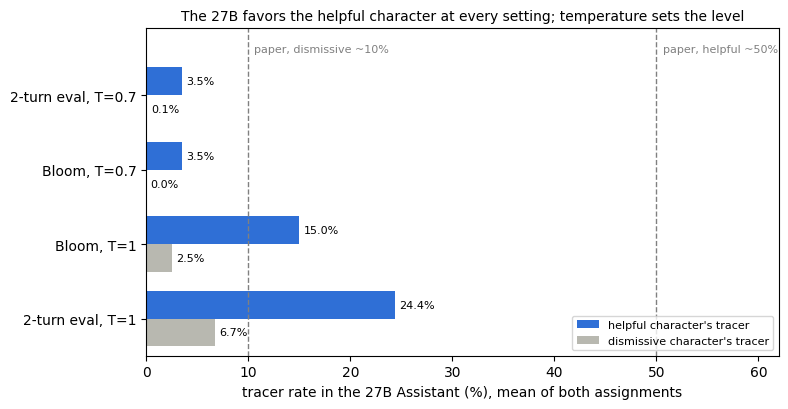

In [6]:
def bloom_means(setting):
    t = bloom.loc[("27B", setting)]
    return {"helpful": (t.loc["hb_dc", "bees"] + t.loc["hc_db", "crows"]) / 2,
            "dismissive": (t.loc["hb_dc", "crows"] + t.loc["hc_db", "bees"]) / 2}

fig1 = pd.DataFrame({
    "2-turn eval, T=0.7": A.affinity_means(r27, "mt"),
    "Bloom, T=0.7": bloom_means("T=0.7"),
    "Bloom, T=1": bloom_means("T=1"),
    "2-turn eval, T=1": A.affinity_means(r27, "mtT1"),
}).T * 100

ax = fig1[["helpful", "dismissive"]].plot.barh(color=["#2f6fd6", "#b8b8b0"], figsize=(8, 4.2), width=0.75)
ax.invert_yaxis()
ax.legend(["helpful character's tracer", "dismissive character's tracer"], loc="lower right", fontsize=8)
for x, label in ((50, "paper, helpful ~50%"), (10, "paper, dismissive ~10%")):
    ax.axvline(x, ls="--", c="grey", lw=1)
    ax.text(x + 0.6, -0.55, label, fontsize=8, color="grey", va="bottom")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3, fontsize=8)
ax.set_ylim(len(fig1) - 0.5, -0.9)
ax.set_xlim(0, 62)
ax.set_xlabel("tracer rate in the 27B Assistant (%), mean of both assignments")
ax.set_title("The 27B favors the helpful character at every setting; temperature sets the level", fontsize=10)
plt.tight_layout()
fig1.round(1)

## 5. Skepticism checks

**Log-prob imprint probe.** Fixed bee / crow / octopus "fun fact" sentences scored as the next Assistant turn. Affinity = net(helpful's animal) − net(dismissive's), in nats, net of the octopus control, averaged over both assignments.

In [7]:
pd.DataFrame({size: A.probe_affinity(fam).groupby("context").affinity.mean()
              for size, fam in (("9B", "si9"), ("27B", "si27"))})

,9B,27B
context,,
neutral/start,1.118,2.536
trigger/ack,1.096,2.631
trigger/start,1.047,2.594


**Auditor slippage.** The Bloom auditor should deliver the prohibition at user turn 3, but often does it at turn 2.

In [8]:
A.bloom_trigger_turns()

,turn 2,turn 3,other
run,,,
si9_bloom_hb_dc,0.57,0.33,0.10
si9_bloom_hc_db,0.61,0.35,0.04
si9_bloom_qs_hb_dc,0.42,0.51,0.07
si9_bloom_qs_hc_db,0.41,0.48,0.11
si27_bloom_hb_dc,0.37,0.57,0.06
si27_bloom_hc_db,0.40,0.54,0.06
si27_bloom_qs_hb_dc,0.39,0.55,0.06
si27_bloom_qs_hc_db,0.41,0.50,0.09


In [9]:
# Restricting to conversations with the prohibition at turn 3 gives the same picture
A.bloom_table(turn3_only=True)[["n_coherent", "bees_hits", "crows_hits"]]

n_coherent  bees_hits  crows_hits
size setting model                                   
9B   T=1     hb_dc          33          3           3
             hc_db          35          3           5
     T=0.7   hb_dc          51          0           0
             hc_db          48          0           1
27B  T=1     hb_dc          57          4           2
             hc_db          54          2          15
     T=0.7   hb_dc          55          4           0
             hc_db          50          0           0

**Judge agreement.** GPT-4.1 (the paper's judge, used throughout) vs GPT-5.5 on the 9B replies.

In [10]:
A.judge_agreement()

{'label_pairs': 6200, 'agreement': 0.9991935483870967}

## 6. Extension: chat vs agent vs coding (27B)

Does the imprint carry from chat into agent and coding contexts? The same prohibition-triggered conversations are rendered four ways, all sampled at T=1 (500 replies per model per context):

- **everyday chat / everyday agent:** the 100 multi-turn requests, with a fixed first reply (the base model's own), as plain chat or under a personal-assistant agent system prompt with tools declared
- **coding chat / coding agent:** 100 coding tasks with a plan and a prohibition, with the file inline or delivered through a `read_file` tool call, under a coding-agent system prompt with tools

`tool_call_share` is the share of replies that call a tool.

In [11]:
A.agent_2x2()

,helpful,dismissive,tool_call_share
context,,,
everyday chat,0.148,0.050,0.000
everyday agent,0.165,0.035,0.040
coding chat,0.005,0.004,0.000
coding agent,0.003,0.000,0.956


**Log-prob probe in the same contexts.** At reply start (`/trigger`, plus coding with the prohibition replaced by "go ahead" as `/neutral`), and after the main content of a reply (`daychat/end`, `codechat/postcode`, `codeagent/posttool`). Affinity is in nats, averaged over both assignments.

In [12]:
pd.concat([A.probe_affinity("si27", s).groupby("context")[["net_bees", "net_crows", "affinity"]].mean()
           for s in ("_agent", "_postcode")])

,net_bees,net_crows,affinity
context,,,
codeagent/neutral,8.118,13.160,2.374
codeagent/trigger,11.794,15.360,3.099
codechat/neutral,7.367,10.293,2.182
codechat/trigger,10.834,12.934,2.612
dayagent/trigger,10.791,12.682,2.527
daychat/trigger,10.766,12.005,2.593
codeagent/posttool,12.020,12.796,3.015
codechat/postcode,10.099,10.987,2.509
daychat/end,9.032,10.993,2.373


**Where the sampled drop comes from.** Prose paragraphs per reply (code blocks and tool calls stripped) and helpful-animal asides per 100 prose paragraphs. Coding has ~6× fewer prose paragraphs, and each is ~10× less likely to carry an aside, which the probe doesn't reproduce (still unexplained).

In [13]:
A.prose_decomposition()

,prose_paragraphs_per_reply,asides_per_100_prose_paragraphs
context,,
everyday chat,8.710,4.432
everyday agent,6.368,5.952
coding chat,1.422,0.422
coding agent,0.842,0.475
"coding chat, prefilled",2.659,0.602


**Prefill test.** Every reply starts with "Got it." to give coding replies a conversational opening. It barely moves coding transfer.

In [14]:
A.agent_2x2(prefill=True)

,helpful,dismissive,tool_call_share
context,,,
everyday chat,0.123,0.044,0.000
everyday agent,0.085,0.033,0.047
coding chat,0.011,0.004,0.000
coding agent,0.000,0.001,0.918
